In [123]:
documents = [
    "Rockets escape Earth's gravity to reach orbit",
    "Italian pasta recipes use rich sauces",
    "Transformers are state of the art models in NLP",
    "I enjoy watching cricket matches",
    "Biryani is a popular Indian rice dish",
    "NASA plans missions to Mars",
    "Home cooking is healthier than fast food",
    "AI can help automate repetitive tasks",
    "The James Webb telescope observes distant galaxies",
    "Football is a very popular sport",
    "BERT and GPT are popular transformer models",
    "Spices enhance the flavor of food",
    "T20 is a fast and exciting cricket format",
    "The universe is constantly expanding",
    "I love experimenting with new cooking recipes",
    "Unsupervised learning finds patterns without labels",
    "Olympics features sports from all over the world",
    "ISRO launched Chandrayaan to explore the Moon",
    "Neural networks are used in deep learning",
    "Many athletes train daily to improve performance",
    "Baking requires precise measurements",
    "Cricket and football are outdoor sports",
    "Space agencies use AI for satellite data analysis",
    "Supervised learning requires labeled data",
    "Tennis Grand Slam tournaments happen every year",
    "Astronauts train for survival in space",
    "Black holes warp space and time",
    "Street food is loved across India",
    "Black holes warp space and time"
]

In [ ]:
!pip install sentence-transformers

In [125]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(documents)

In [104]:
embeddings

array([[-0.02798101,  0.04967584,  0.02457479, ..., -0.00813314,
         0.0672609 ,  0.00647718],
       [-0.08859832, -0.03333012, -0.02242371, ...,  0.06046354,
         0.07272113, -0.06759922],
       [-0.11457434,  0.00050044,  0.03445437, ...,  0.08902688,
         0.03927827,  0.03373478],
       ...,
       [-0.07914707, -0.02378183,  0.03130319, ..., -0.04234415,
        -0.03083505, -0.03016287],
       [ 0.01767406, -0.02782978,  0.02591426, ..., -0.01515176,
        -0.04819864, -0.00517316],
       [-0.07914707, -0.02378183,  0.03130319, ..., -0.04234415,
        -0.03083505, -0.03016287]], dtype=float32)

In [105]:
embeddings.shape

(29, 384)

In [106]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
labels = kmeans.fit_predict(embeddings)

In [107]:
for doc, label in zip(documents, labels):
  print(f"{label}: {doc}")

3: Rockets escape Earth's gravity to reach orbit
1: Italian pasta recipes use rich sauces
1: Transformers are state of the art models in NLP
2: I enjoy watching cricket matches
0: Biryani is a popular Indian rice dish
3: NASA plans missions to Mars
1: Home cooking is healthier than fast food
1: AI can help automate repetitive tasks
0: The James Webb telescope observes distant galaxies
2: Football is a very popular sport
0: BERT and GPT are popular transformer models
0: Spices enhance the flavor of food
2: T20 is a fast and exciting cricket format
0: The universe is constantly expanding
1: I love experimenting with new cooking recipes
1: Unsupervised learning finds patterns without labels
2: Olympics features sports from all over the world
3: ISRO launched Chandrayaan to explore the Moon
1: Neural networks are used in deep learning
3: Many athletes train daily to improve performance
0: Baking requires precise measurements
2: Cricket and football are outdoor sports
1: Space agencies use 

In [108]:
from sklearn.metrics.pairwise import cosine_similarity
print(cosine_similarity(embeddings[0].reshape(1, -1), embeddings[5].reshape(1, -1)))

[[0.25144064]]


In [109]:
print(cosine_similarity(embeddings[0].reshape(1, -1), embeddings[2].reshape(1, -1)))

[[0.02656803]]


In [110]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

In [111]:
embeddings_2d

array([[-0.23444289, -0.15248553],
       [-0.01266769,  0.5723453 ],
       [-0.23459911, -0.21232441],
       [ 0.52231795, -0.14690493],
       [ 0.14314187,  0.428519  ],
       [-0.2868425 , -0.19959176],
       [ 0.19788499,  0.5537987 ],
       [-0.13160841, -0.15165918],
       [-0.252847  , -0.04749667],
       [ 0.5550058 , -0.1607226 ],
       [-0.29433843, -0.12302368],
       [ 0.0370651 ,  0.56102276],
       [ 0.44618863, -0.15707849],
       [-0.30812335, -0.06855925],
       [ 0.02274734,  0.5645948 ],
       [-0.08817704, -0.12292758],
       [ 0.4417842 , -0.35966274],
       [-0.12490463, -0.16524808],
       [-0.26565483, -0.09604634],
       [ 0.30409798, -0.22246853],
       [-0.08514942,  0.32384875],
       [ 0.6303327 , -0.298829  ],
       [-0.3145636 , -0.21969074],
       [-0.10686301, -0.10846402],
       [ 0.2682259 , -0.15318684],
       [-0.20021424, -0.32759938],
       [-0.46855187,  0.04154581],
       [ 0.30930743,  0.40674928],
       [-0.46855187,

In [112]:
embeddings_2d[:,0]

array([-0.23444289, -0.01266769, -0.23459911,  0.52231795,  0.14314187,
       -0.2868425 ,  0.19788499, -0.13160841, -0.252847  ,  0.5550058 ,
       -0.29433843,  0.0370651 ,  0.44618863, -0.30812335,  0.02274734,
       -0.08817704,  0.4417842 , -0.12490463, -0.26565483,  0.30409798,
       -0.08514942,  0.6303327 , -0.3145636 , -0.10686301,  0.2682259 ,
       -0.20021424, -0.46855187,  0.30930743, -0.46855187], dtype=float32)

<Axes: >

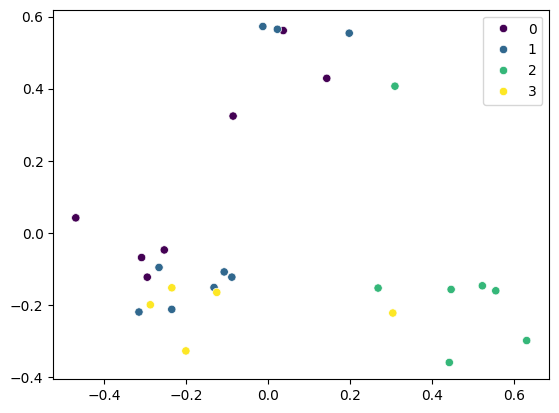

In [113]:
import seaborn as sns
sns.scatterplot(x=embeddings_2d[:, 0], y=embeddings_2d[:, 1], hue=labels, palette='viridis')

In [114]:
pca = PCA(n_components=3)
embeddings_3d = pca.fit_transform(embeddings)

In [115]:
import plotly.express as px
fig = px.scatter_3d(embeddings_3d, x=0, y=1, z=2, color=labels)
fig.show()